In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

DATA_PATH = "../data/processed/cleaned_accidents.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (20000, 23)


In [2]:
coords = df[["latitude", "longitude"]].values

print("Coordinate points:", len(coords))

Coordinate points: 20000


In [3]:
from sklearn.neighbors import NearestNeighbors

# 5 nearest neighbors
k = 5

neighbors = NearestNeighbors(
    n_neighbors=k,
    metric="haversine"
)

# Convert degrees to radians
coords_rad = np.radians(coords)

neighbors.fit(coords_rad)

distances, indices = neighbors.kneighbors(coords_rad)

# Distance to the 5th nearest neighbor
k_distances = distances[:, -1]

# Convert radians to kilometers
EARTH_RADIUS_KM = 6371.0

k_distances_km = k_distances * EARTH_RADIUS_KM

k_distances_km = np.sort(k_distances_km)

print("5th-nearest-neighbor distance statistics:")
print(pd.Series(k_distances_km).describe())

5th-nearest-neighbor distance statistics:
count    20000.000000
mean         0.822750
std          0.310230
min          0.095517
25%          0.591166
50%          0.788622
75%          1.015771
max          2.630720
dtype: float64


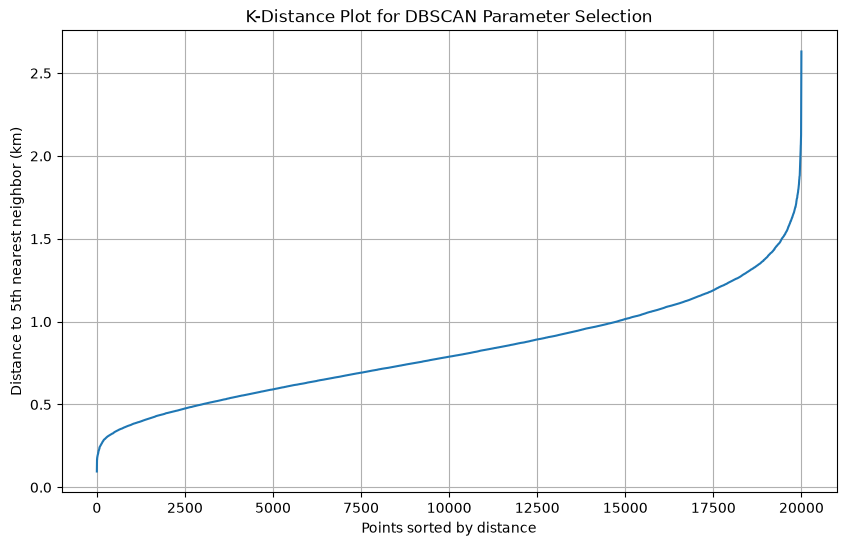

In [4]:
plt.figure(figsize=(10, 6))

plt.plot(k_distances_km)

plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to 5th nearest neighbor (km)")
plt.title("K-Distance Plot for DBSCAN Parameter Selection")

plt.grid(True)
plt.show()

In [5]:
print("========== DBSCAN PARAMETER COMPARISON ==========")

candidate_eps_km = [0.8, 1.0, 1.2, 1.4, 1.5, 1.6, 1.8, 2.0]
min_samples = 5

results = []

for eps_km in candidate_eps_km:

    # Convert kilometers to radians
    eps_rad = eps_km / EARTH_RADIUS_KM

    model = DBSCAN(
        eps=eps_rad,
        min_samples=min_samples,
        metric="haversine"
    )

    labels = model.fit_predict(coords_rad)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    noise_percentage = (n_noise / len(labels)) * 100

    results.append({
        "eps_km": eps_km,
        "clusters": n_clusters,
        "noise_points": n_noise,
        "noise_percentage": noise_percentage
    })

comparison = pd.DataFrame(results)

display(comparison)

========== DBSCAN PARAMETER COMPARISON ==========


,eps_km,clusters,noise_points,noise_percentage
0,0.8,718,6006,30.030
1,1.0,526,2325,11.625
2,1.2,181,651,3.255
3,1.4,52,121,0.605
4,1.5,21,61,0.305
5,1.6,10,27,0.135
6,1.8,8,3,0.015
7,2.0,8,0,0.000


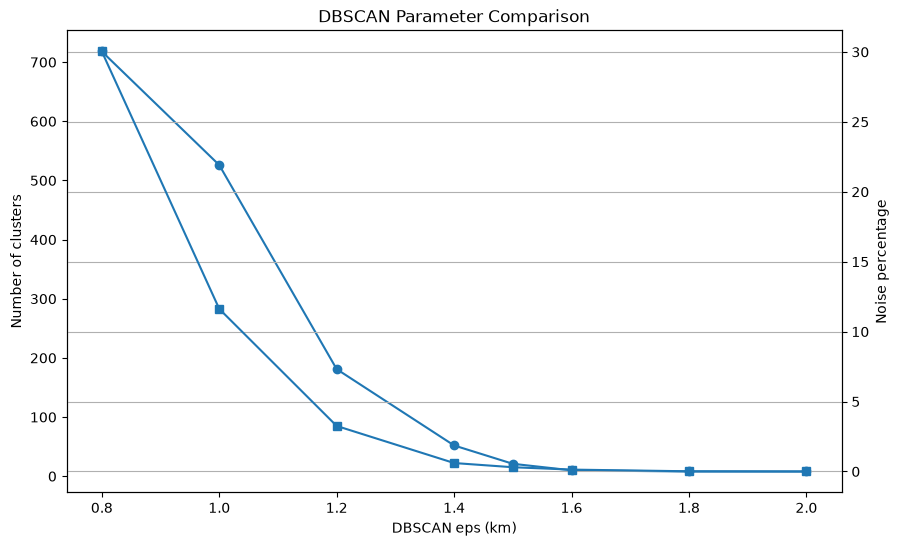

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(
    comparison["eps_km"],
    comparison["clusters"],
    marker="o"
)

ax1.set_xlabel("DBSCAN eps (km)")
ax1.set_ylabel("Number of clusters")

ax2 = ax1.twinx()

ax2.plot(
    comparison["eps_km"],
    comparison["noise_percentage"],
    marker="s"
)

ax2.set_ylabel("Noise percentage")

plt.title("DBSCAN Parameter Comparison")
plt.grid(True)

plt.show()

In [9]:
print("========== DBSCAN WITH EPS = 1.4 KM ==========")

EPS_KM = 1.4
MIN_SAMPLES = 5

eps_rad = EPS_KM / EARTH_RADIUS_KM

dbscan = DBSCAN(
    eps=eps_rad,
    min_samples=MIN_SAMPLES,
    metric="haversine"
)

df["cluster"] = dbscan.fit_predict(coords_rad)

n_clusters = len(set(df["cluster"])) - (1 if -1 in df["cluster"].values else 0)

print("Number of clusters:", n_clusters)
print("Noise points:", (df["cluster"] == -1).sum())
cluster_sizes = (
    df[df["cluster"] != -1]
    .groupby("cluster")
    .size()
    .reset_index(name="accident_count")
    .sort_values("accident_count", ascending=False)
)

print("========== CLUSTER SIZE DISTRIBUTION ==========")

display(cluster_sizes.describe())

print("\nTop 20 clusters:")
display(cluster_sizes.head(20))

========== DBSCAN WITH EPS = 1.4 KM ==========
Number of clusters: 52
Noise points: 121
========== CLUSTER SIZE DISTRIBUTION ==========


,cluster,accident_count
count,52.000000,52.000000
mean,25.500000,382.288462
std,15.154757,871.084817
min,0.000000,2.000000
25%,12.750000,7.000000
50%,25.500000,11.000000
75%,38.250000,28.500000
max,51.000000,2577.000000



Top 20 clusters:


,cluster,accident_count
2,2,2577
3,3,2575
6,6,2559
0,0,2517
1,1,2480
4,4,2408
5,5,2380
7,7,1572
10,10,181
8,8,124


In [13]:
print("========== CLUSTER CITY CONSISTENCY ==========")

cluster_city = (
    df[df["cluster"] != -1]
    .groupby("cluster")["city"]
    .nunique()
    .reset_index(name="unique_cities")
)

print("Clusters containing multiple cities:")
display(
    cluster_city[cluster_city["unique_cities"] > 1]
)

========== CLUSTER CITY CONSISTENCY ==========
Clusters containing multiple cities:


,cluster,unique_cities


In [14]:
hotspot_summary = (
    df[df["cluster"] != -1]
    .groupby("cluster")
    .agg(
        city=("city", lambda x: x.mode()[0]),
        accident_count=("accident_id", "count"),
        center_latitude=("latitude", "mean"),
        center_longitude=("longitude", "mean"),
        fatal_accidents=(
            "accident_severity",
            lambda x: (x == "fatal").sum()
        ),
        major_accidents=(
            "accident_severity",
            lambda x: (x == "major").sum()
        ),
        minor_accidents=(
            "accident_severity",
            lambda x: (x == "minor").sum()
        ),
        total_casualties=("casualties", "sum")
    )
    .reset_index()
    .sort_values("accident_count", ascending=False)
)

display(hotspot_summary.head(20))

,cluster,city,accident_count,center_latitude,center_longitude,fatal_accidents,major_accidents,minor_accidents,total_casualties
2,2,Chandigarh,2577,30.698616,76.801333,378,780,1419,4377
3,3,Chennai,2575,13.001594,80.200036,371,794,1410,4567
6,6,Kolkata,2559,22.550071,88.353031,377,737,1445,4508
0,0,Pune,2517,18.550879,73.852559,398,729,1390,4419
1,1,Mumbai,2480,19.051506,72.849384,359,795,1326,4280
4,4,Bangalore,2408,12.998567,77.599456,378,702,1328,4075
5,5,Hyderabad,2380,17.401092,78.403541,336,742,1302,4011
7,7,Delhi,1572,28.647978,77.040924,255,441,876,2768
10,10,Delhi,181,28.577812,77.163033,27,59,95,280
8,8,Delhi,124,28.822155,76.848124,23,22,79,234
